In [1]:
import os
import cv2
import numpy as np
import random
from ultralytics import YOLO
import matplotlib.pyplot as plt

In [2]:
dir_base = "data"
dir_train = os.path.join(dir_base, "Train")

Selecciono un número de imágenes de diferentes clases de forma aleatoria, para aplicar el HSV a esas

In [3]:
def seleccionar_imagenes_aleatorias(dir_train, num_total=20, semilla=42):
    random.seed(semilla)
    clases_dirs = [os.path.join(dir_train, d) for d in os.listdir(dir_train) if os.path.isdir(os.path.join(dir_train, d))]
    todas_imagenes = []
    for clase_dir in clases_dirs:
        for img in os.listdir(clase_dir):
            if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                todas_imagenes.append(os.path.join(clase_dir, img))
    return random.sample(todas_imagenes, min(num_total, len(todas_imagenes)))

imagenes_muestra = seleccionar_imagenes_aleatorias(dir_train, num_total=20, semilla=1234) #20 imgs
print(f"Se han seleccionado {len(imagenes_muestra)} imágenes para el análisis.\n")

Se han seleccionado 20 imágenes para el análisis.



Cargar modelo - YOLO 

In [4]:
model = YOLO("models/traffic_sign_detector.pt")

Rangos HSV: busco los colores que me interesan en las señales

In [5]:
rangos_hsv = {
    "rojo1": [(0, 40, 40), (10, 255, 255)],
    "rojo2": [(160, 40, 40), (180, 255, 255)],
    "amarillo": [(15, 60, 60), (40, 255, 255)],
    "azul": [(90, 50, 50), (130, 255, 255)]
}

Como dependiendo del color del borde, del fondo y de su forma, la señal indica una cosa u otra, es muy importante conocer estos atributos

In [6]:
def clasificar_tipo(color_predominante, forma, fondo=None, borde=None):

    # Señales de advertencia, prohibición, obligación, sugerencia
    if color_predominante in ["rojo1", "rojo2"]:
        if forma == "triangulo":
            return "Advertencia"      # Triángulo rojo
        elif forma == "circulo":
            return "Prohibición"      # Círculo rojo
    elif color_predominante == "azul":
        if forma == "circulo":
            return "Obligación"       # Círculo azul
        elif forma == "cuadrado":
            return "Sugerencia"       # Cuadrado azul
        elif forma == "rectangulo":
            return "Indicación general"  # Rectángulo azul
    elif color_predominante == "amarillo":
        return "Precaución"           # Triángulo amarillo (por obras u otras advertencias)

    # Señales de fin de prohibición
    if borde == "negro" and fondo == "blanco":
        return "Fin de prohibición"

    # Señales de obras (fondo amarillo)
    if fondo == "amarillo":
        return "Obras"

    # Señales de indicaciones generales adicionales
    if color_predominante == "azul" and forma == "rectangulo":
        return "Indicación general"

    return "Otro"

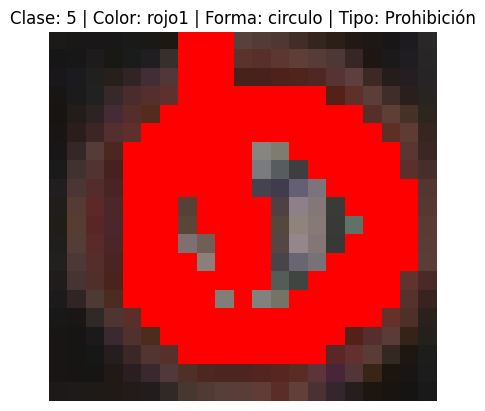

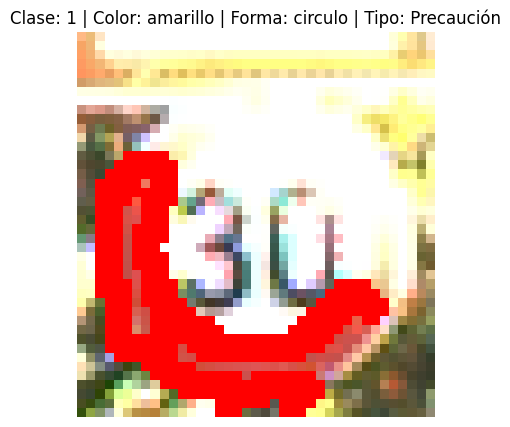

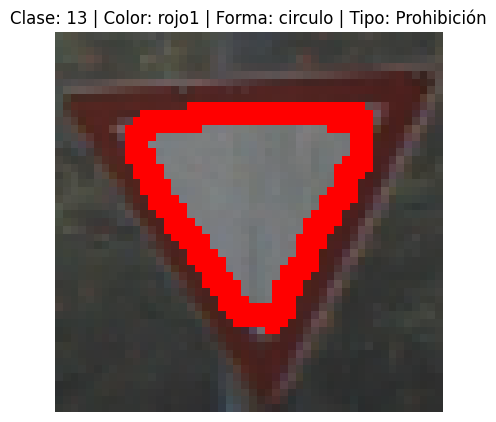

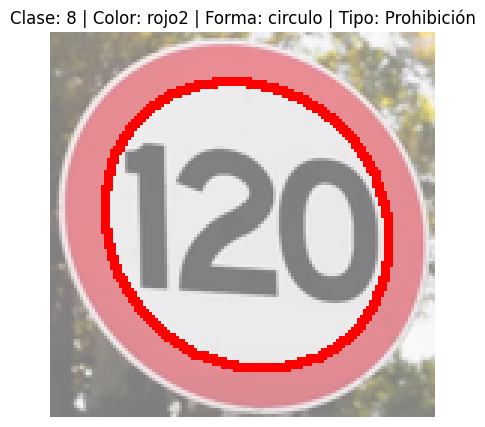

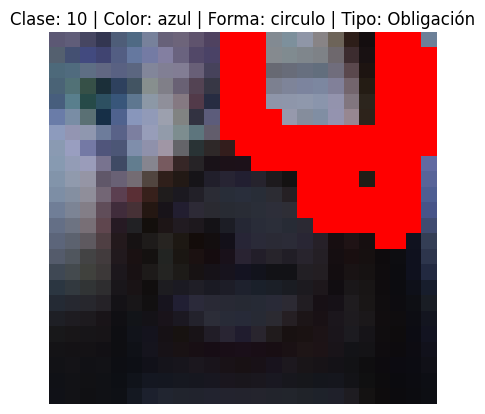

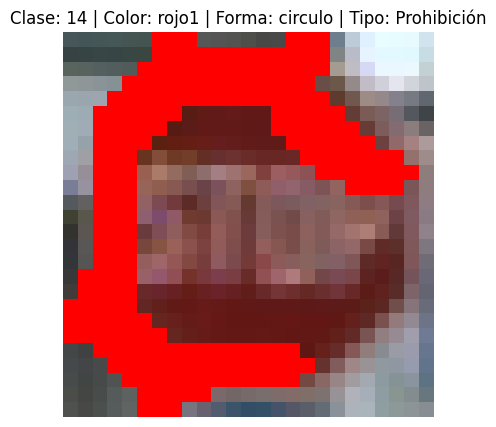

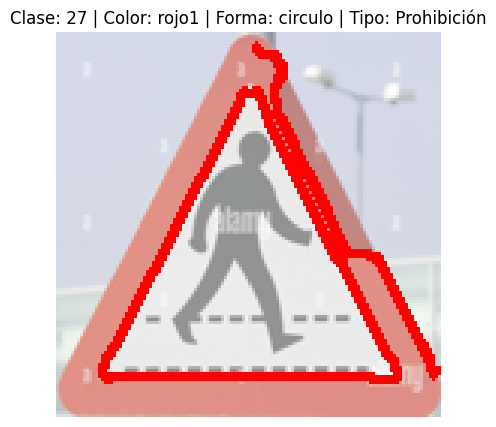

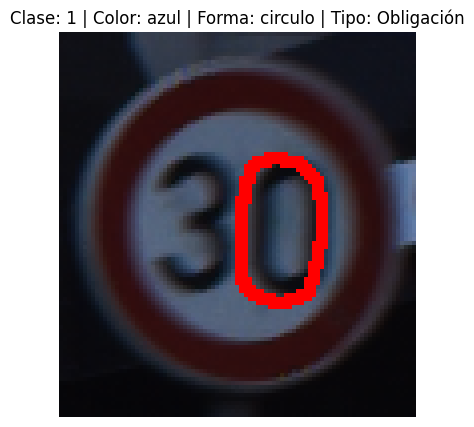

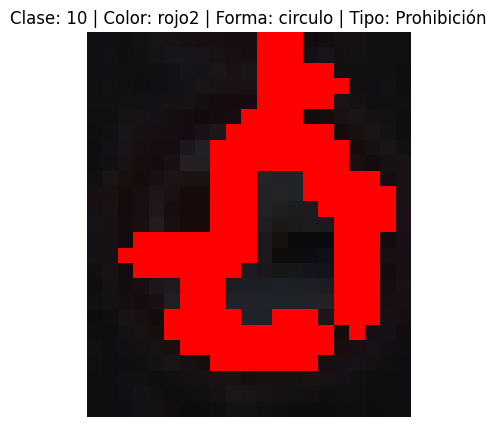

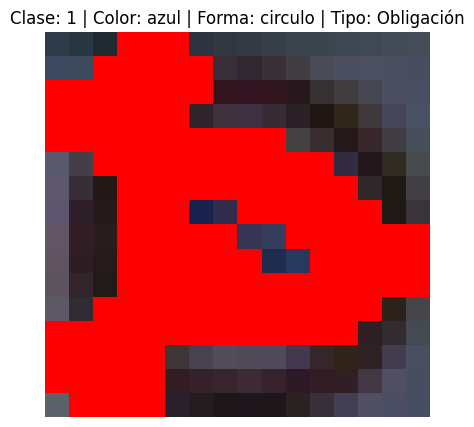

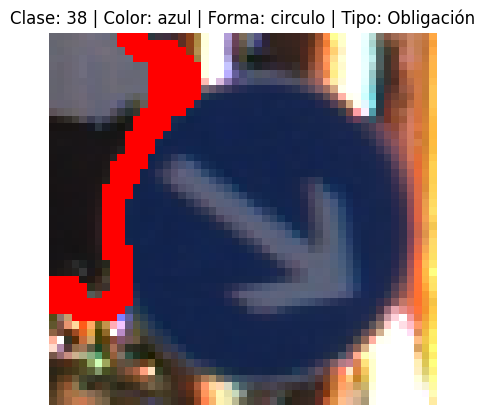

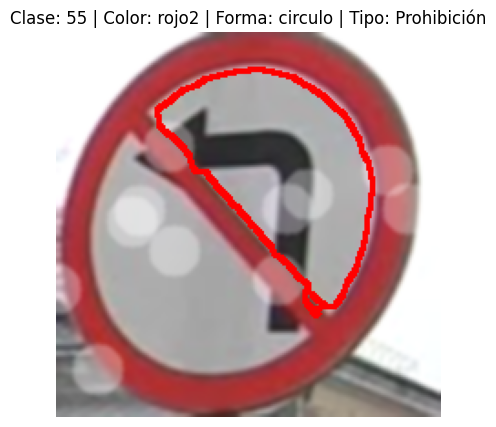

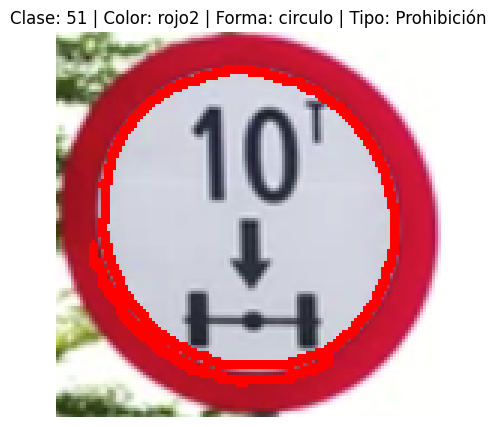

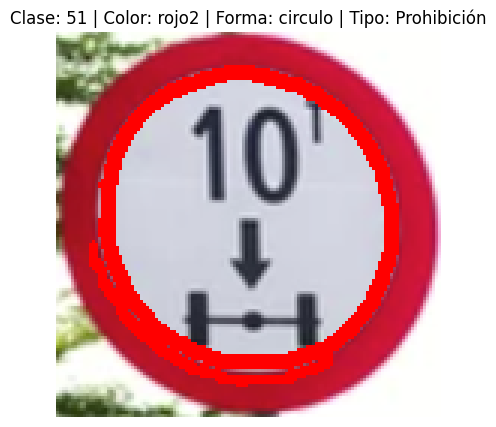

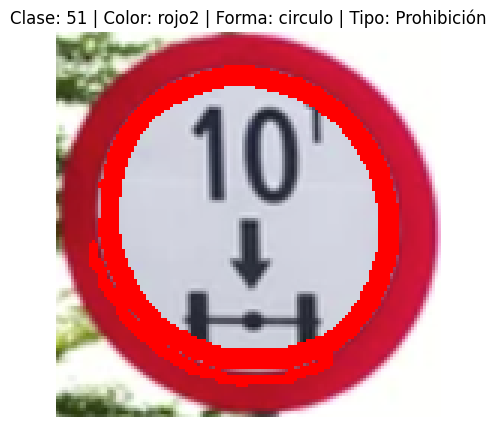

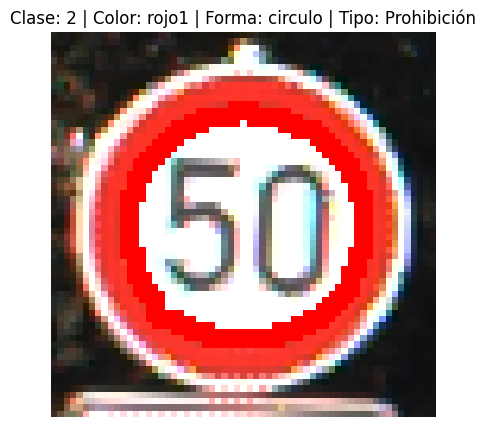

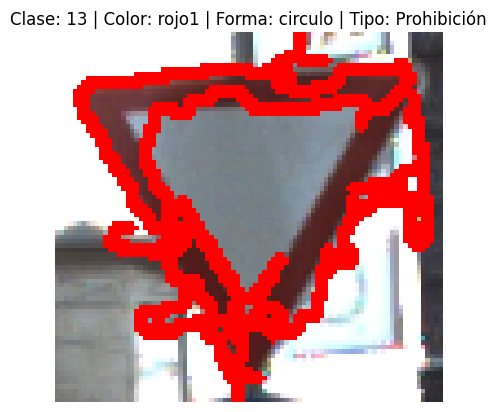

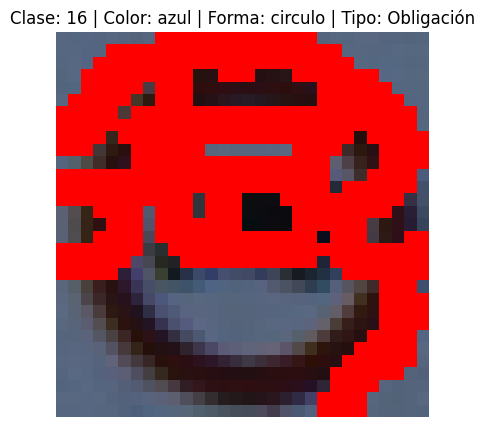

In [7]:
# PROCESAMIENTO
for img_path in imagenes_muestra:
    clase = os.path.basename(os.path.dirname(img_path))  # extrae la carpeta, que es la clase
    img = cv2.imread(img_path)
    if img is None:
        continue

    results = model(img, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy().astype(int)

    for box in boxes:
        x1, y1, x2, y2 = box
        w_box = x2 - x1
        h_box = y2 - y1

        # Agregar margen proporcional al tamaño de la señal
        margin_x = int(0.1 * w_box)  # 10% del ancho
        margin_y = int(0.1 * h_box)  # 10% del alto

        x1_pad = max(0, x1 - margin_x)
        x2_pad = min(img.shape[1], x2 + margin_x)
        y1_pad = max(0, y1 - margin_y)
        y2_pad = min(img.shape[0], y2 + margin_y)

        recorte = img[y1_pad:y2_pad, x1_pad:x2_pad]
        if recorte.size == 0:
            continue

        hsv = cv2.cvtColor(recorte, cv2.COLOR_BGR2HSV)
        h, s, v = cv2.split(hsv)
        v_eq = cv2.equalizeHist(v)
        hsv_eq = cv2.merge((h, s, v_eq))
        height, width, _ = recorte.shape

        # Máscara total combinada
        mask_total = np.zeros((height, width), dtype=np.uint8)
        for nombre, (lower, upper) in rangos_hsv.items():
            mask = cv2.inRange(hsv_eq, np.array(lower), np.array(upper))
            mask_total = cv2.bitwise_or(mask_total, mask)

        # Suavizar la máscara y definir borde
        '''
        mask_total = cv2.morphologyEx(mask_total, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8))
        mask_total = cv2.morphologyEx(mask_total, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
        borde = cv2.Canny(mask_total, 50, 150)
        '''

        mask_total = cv2.GaussianBlur(mask_total, (5, 5), 0)
        mask_total = cv2.morphologyEx(mask_total, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8))
        mask_total = cv2.morphologyEx(mask_total, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))

        # Borde y contornos
        borde = cv2.Canny(mask_total, 50, 150)

        contornos, _ = cv2.findContours(borde, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contornos:
            continue

        contorno_principal = max(contornos, key=cv2.contourArea)
        perimetro = cv2.arcLength(contorno_principal, True)
        approx = cv2.approxPolyDP(contorno_principal, 0.02 * perimetro, True)
        vertices = len(approx)

        # Clasificación geométrica - dependiendo de los vértices es una figura u otra
        forma = "indefinida"      

        if vertices == 3:
            forma = "triangulo"
        elif 4 <= vertices <= 5:
            # Analizar aspecto para diferenciar cuadrado/rectángulo
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = float(w) / h
            if 0.9 <= aspect_ratio <= 1.1:
                forma = "cuadrado"
            else:
                forma = "rectangulo"
        elif vertices > 5:
            forma = "circulo"
        else:
            forma = "indefinida"

        # Color predominante en el borde
        porcentajes = {}
        for nombre, (lower, upper) in rangos_hsv.items():
            mask_color = cv2.inRange(hsv_eq, np.array(lower), np.array(upper))
            mask_borde_color = cv2.bitwise_and(mask_color, mask_total)
            porcentaje = (cv2.countNonZero(mask_borde_color) / (height * width)) * 100
            porcentajes[nombre] = porcentaje

        color_borde = max(porcentajes, key=porcentajes.get)

        #color predominnate en el fondo
        mask_fondo = cv2.bitwise_not(mask_total)
        porcentajes_fondo = {}
        for nombre, (lower, upper) in rangos_hsv.items():
            mask_color = cv2.inRange(hsv_eq, np.array(lower), np.array(upper))
            mask_fondo_color = cv2.bitwise_and(mask_color, mask_fondo)
            porcentaje = (cv2.countNonZero(mask_fondo_color) / (height * width)) * 100
            porcentajes_fondo[nombre] = porcentaje

        color_fondo = max(porcentajes_fondo, key=porcentajes_fondo.get)

        tipo_senal = clasificar_tipo(color_borde, forma, fondo=color_fondo, borde=color_borde)

        # Dibujar resultado
        cv2.drawContours(recorte, [contorno_principal], -1, (0, 0, 255), 2)

        # Mostrar resultado
        plt.figure(figsize=(5, 5))
        plt.imshow(cv2.cvtColor(recorte, cv2.COLOR_BGR2RGB))
        plt.title(f"Clase: {clase} | Color: {color_borde} | Forma: {forma} | Tipo: {tipo_senal}")
        plt.axis("off")
        plt.show()